In [12]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
def create_superposition_circuit() -> QuantumCircuit:
    """
    Constructs a 1-qubit circuit implementing a Hadamard gate 
    to achieve the state: 1/sqrt(2) * (|0> + |1>).
    """
    # Initialize circuit with 1 qubit and 1 classical bit
    qc = QuantumCircuit(1, 1)
    
    # Apply Hadamard gate to put the qubit in superposition
    qc.h(0)
    
    # Measure the qubit into the classical bit
    qc.measure(0, 0)
    
    return qc

In [ ]:
def run_simulation(circuit: QuantumCircuit, total_shots: int = 500):
    """
    Executes the circuit using the V2 Sampler primitive.
    Note: We wrap 'circuit' in a list [] to satisfy the PUB requirement.
    """
    sampler = Sampler()
    
    # The fix: wrap circuit in a list
    job = sampler.run([circuit], shots=total_shots) 
    result = job.result()
    
    # In V2, results are accessed via index for each PUB
    pub_result = result[0]
    
    # Get counts/probabilities from the classical register (usually 'c')
    counts = pub_result.data.c.get_counts()
    return counts

Circuit Diagram:
     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 

Measurement results: {'1': 252, '0': 248}


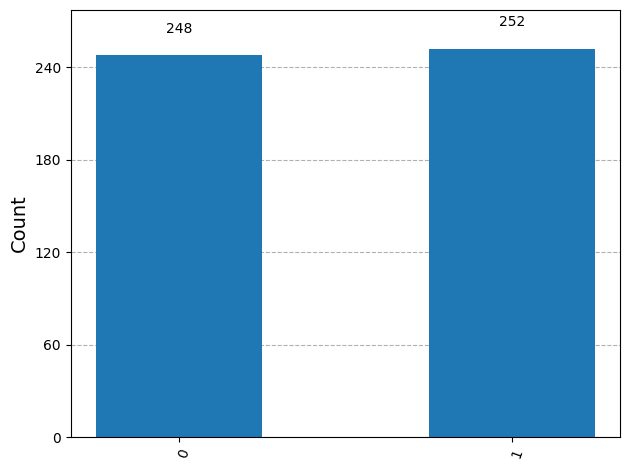

In [ ]:
if __name__ == "__main__":
    circuit = create_superposition_circuit()
    
    # Visualize the circuit
    print("Circuit Diagram:")
    print(circuit.draw(output='text'))
    
    # Run and plot results
    results = run_simulation(circuit, total_shots=500)
    print(f"\nMeasurement results: {results}")
    
    plot_histogram(results)
    plt.show()